# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

### Package Loading

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)
library(patchwork)
library(lmtest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/zhong/AppData/Local/R/win-library/4.4/units/share/udunits/udunits2.xml

Linking to GEOS 3.13.0, GDAL 3.10.1, PROJ 9.5.1; sf_use_s2() is TRUE

载入需要的程序包：zoo


载入程序包：'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021
census2021 <- read_csv("census2021_raw.csv")|>
    glimpse()


Rows: 1016 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Type
dbl (12): GeoUID, Region Name, Area (sq km), Population, Dwellings, Househol...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,016
Columns: 13
$ GeoUID                                                                <dbl> …
$ Type                                                                  <chr> …
$ `Region Name`                                                         <dbl> …
$ `Area (sq km)`                                                        <dbl> …
$ Population                                                            <dbl> …
$ Dwellings                                                             <dbl> …
$ Households                                                            <dbl> …
$ `v_CA21_1: Population, 2021`                                          <dbl> …
$ `v_CA21_6: Population density per square kilometre`                   <dbl> …
$ `v_CA21_386: Average age`                                             <dbl> …
$ `v_CA21_906: Median total income of household in 2020 ($)`            <dbl> …
$ `v_CA21_5853: University certificate or diploma above bachelor level` <dbl> …
$ `v_CA21_4410: 

In [3]:
census2021_clean <- census2021|>
    rename(name = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5853: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`)|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(university_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, area_sq_km, age, income, immigrant_prop, university_prop)|>
    glimpse()

census2021_clean$name <- as.character(census2021_clean$name)

Rows: 1,016
Columns: 10
$ name               <dbl> 59150307, 59150308, 59150309, 59150310, 59150311, 5…
$ households         <dbl> 266, 218, 282, 389, 187, 201, 355, 169, 350, 209, 3…
$ dwellings          <dbl> 297, 229, 299, 411, 202, 218, 368, 177, 369, 221, 3…
$ population         <dbl> 677, 541, 761, 748, 537, 555, 1003, 508, 966, 544, …
$ population_density <dbl> 2263.5, 4936.1, 6800.7, 6837.3, 6637.8, 6372.0, 580…
$ area_sq_km         <dbl> 0.2991, 0.1096, 0.1119, 0.1094, 0.0809, 0.0871, 0.1…
$ age                <dbl> 42.8, 43.0, 43.3, 37.0, 41.0, 40.6, 45.6, 41.4, 42.…
$ income             <dbl> 1.14, 1.14, 0.94, 0.67, 0.92, 0.96, 0.90, 0.95, 0.8…
$ immigrant_prop     <dbl> 0.2806499, 0.2957486, 0.2759527, 0.2606952, 0.28864…
$ university_prop    <dbl> 0.01477105, 0.04621072, 0.03285151, 0.01336898, 0.0…


### Data Exploration

In [4]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    rename("university_prop" = "education_prop")|>
    mutate(income = as.double(income),
    immigrant_prop = as.double(immigrant_prop),
    university_prop = as.double(university_prop))|>
    glimpse()

Warning message:
"There were 3 warnings in `stopifnot()`.
The first warning was:
ℹ In argument: `income = as.double(income)`.
Caused by warning:
! 强制改变过程中产生了NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings."


Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [5]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2024)|>
    glimpse()

Rows: 351,457
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [6]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 193,067
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


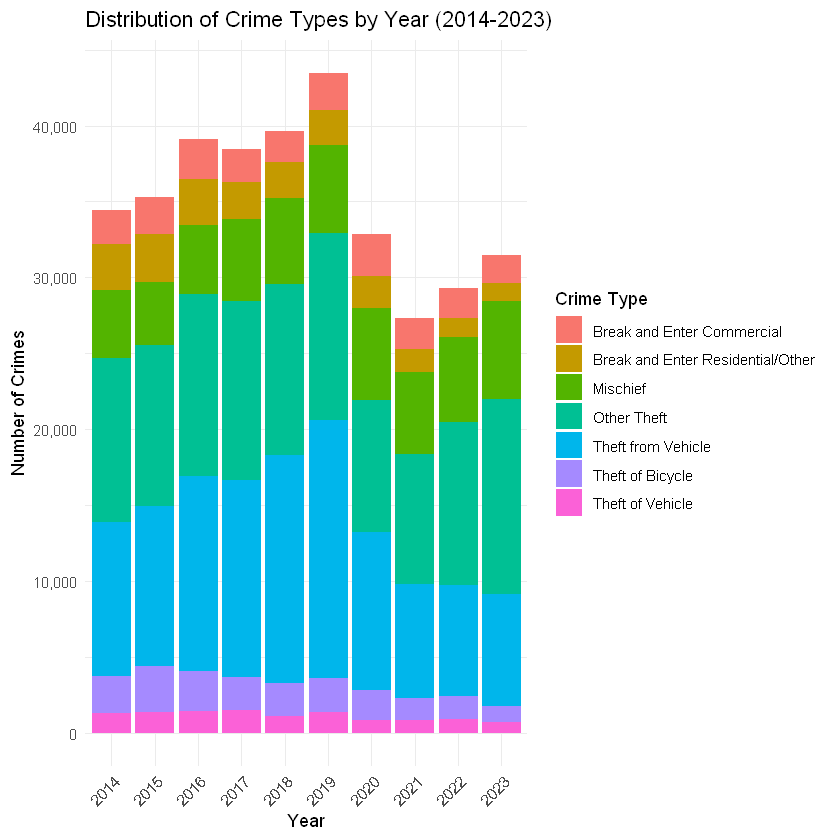

In [7]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [8]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 104,703
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [9]:
crime_trend_complete <- crime_trend %>%
  complete(name, time_category, date = seq.Date(min(date), max(date), by = "month"),
           fill = list(crime_count = 0))


In [45]:
print(sum(crime_trend_complete$crime_count == 0)) 

[1] 133617


#### Converting into Panel

In [48]:
census2016_panel <- merge(census2016, crime_trend_complete, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 238,320
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [56]:
census2016_2021_panel <- census2016_panel %>%
  left_join(census2021_clean, by = "name", suffix = c("", ".new")) |>
  mutate(
    # For each variable, if the date is on or after 2019-01-01, use the new (2021) data; otherwise keep the original
    households = if_else(date >= as.Date("2019-01-01"), households.new, households),
    dwellings = if_else(date >= as.Date("2019-01-01"), dwellings.new, dwellings),
    population = if_else(date >= as.Date("2019-01-01"), population.new, population),
    population_density = if_else(date >= as.Date("2019-01-01"), population_density.new, population_density),
    area_sq_km = if_else(date >= as.Date("2019-01-01"), area_sq_km.new, area_sq_km),
    age = if_else(date >= as.Date("2019-01-01"), age.new, age),
    income = if_else(date >= as.Date("2019-01-01"), income.new, income),
    immigrant_prop = if_else(date >= as.Date("2019-01-01"), immigrant_prop.new, immigrant_prop),
    university_prop = if_else(date >= as.Date("2019-01-01"), university_prop.new, university_prop)
  ) |>
  select(-ends_with(".new"))|>
  glimpse()


Rows: 238,320
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [51]:
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016_2021_panel <- st_make_valid(census2016_2021_panel)


# Compute centroids for census divisions
census2016_centroids <- st_centroid(census2016_2021_panel)

# Perform a spatial join based on whether the census centroid is within the neighborhood boundary
census2016_centroids_joined <- st_join(census2016_centroids, neighborhood_valid[, "neighborhood"], join = st_within)

census2016_2021_panel$neighborhood <- census2016_centroids_joined$neighborhood

glimpse(census2016_2021_panel)


Warning message:
"st_centroid assumes attributes are constant over geometries"


Rows: 238,320
Columns: 23
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service/>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles/>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.
ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ 42 tiles needed, this may take a while (try a smaller zoom?)



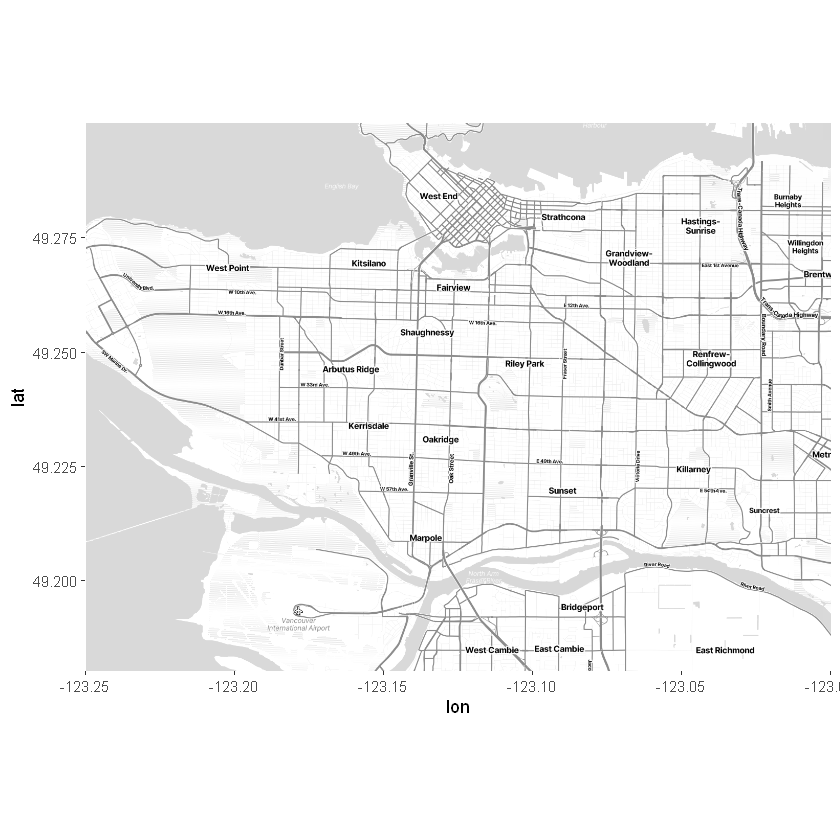

In [23]:
library(ggmap)

key = '953a00a4-1c69-45b1-a0e4-b3492abdf92b'

register_stadiamaps(key, write = FALSE)

bbox <- c(left = -123.25, bottom = 49.18, right = -123.0, top = 49.3)

base <- get_stadiamap(bbox = bbox, zoom = 13, maptype = "stamen_toner_lite", filetype = "svg")
ggmap(base)

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


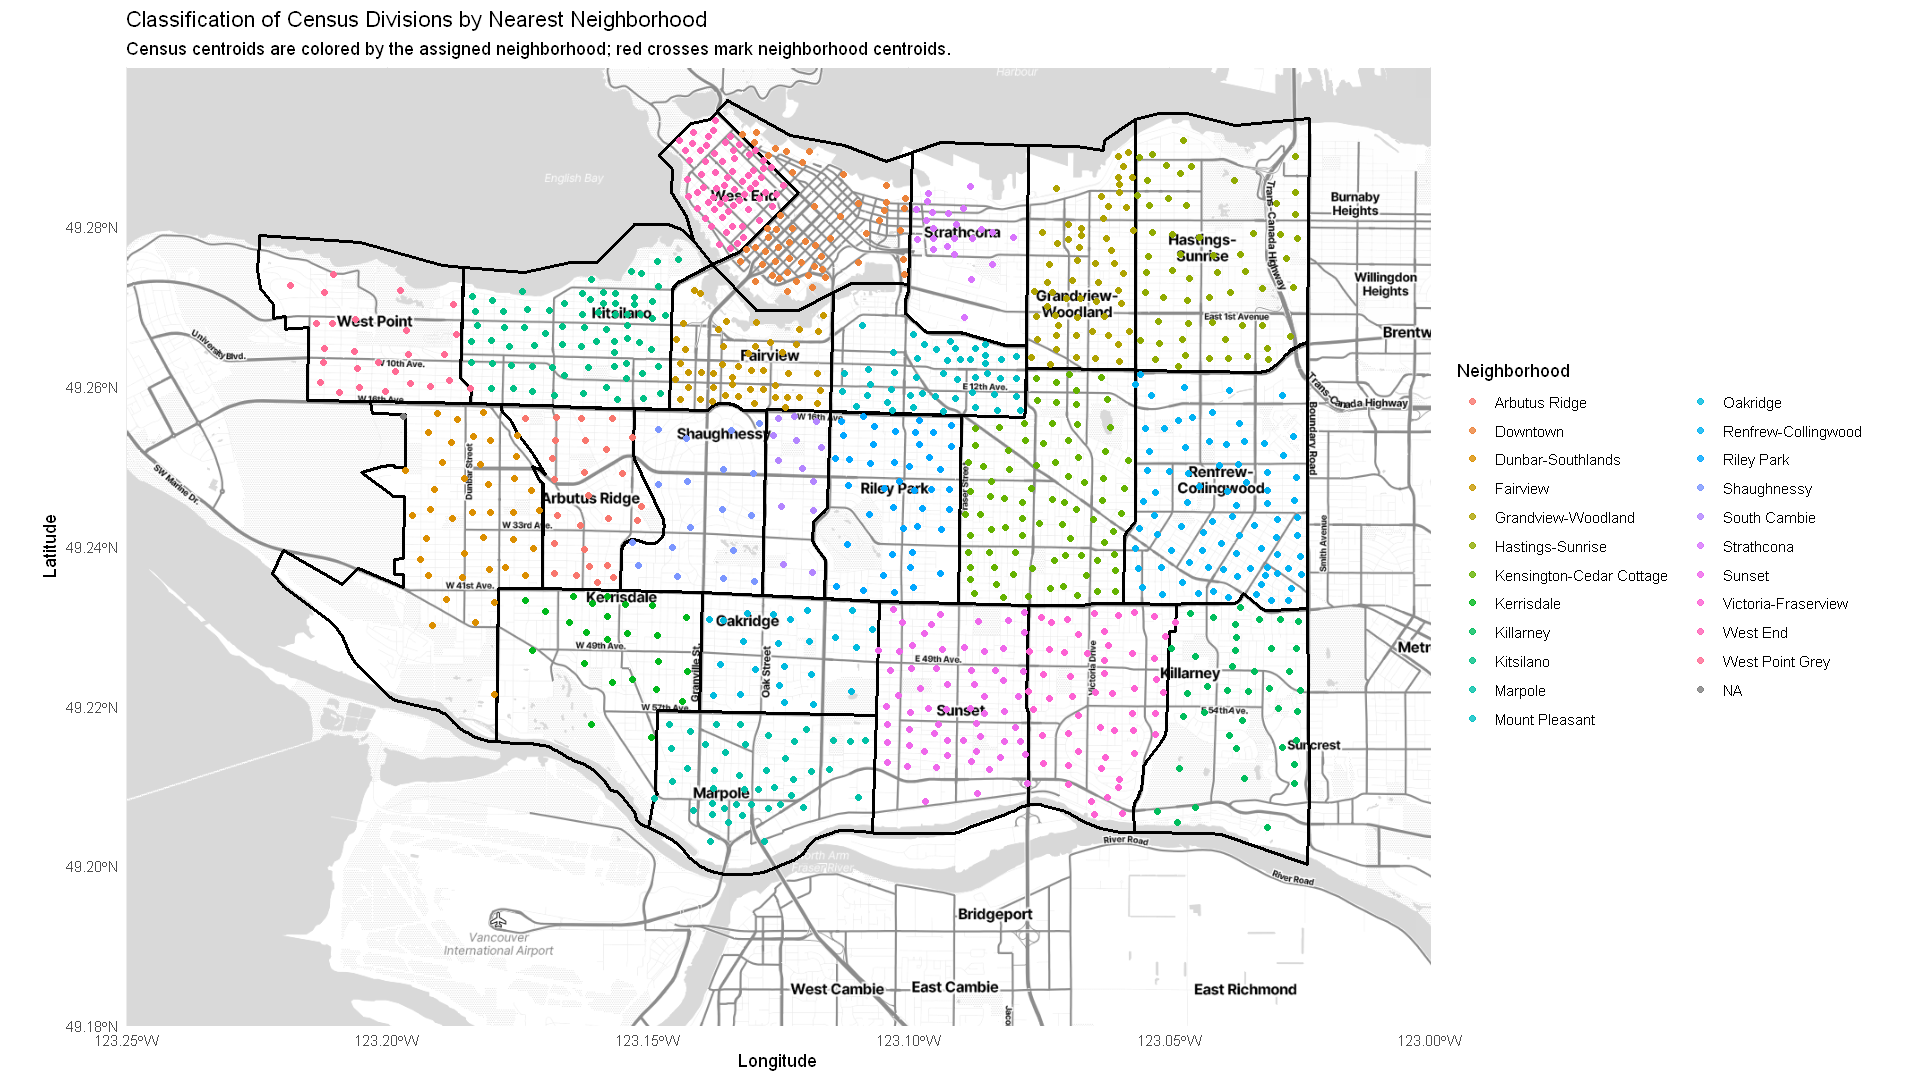

In [24]:
census2016_centroids <- census2016_centroids %>%
  mutate(neighborhood = census2016_2021_panel$neighborhood)

neighborhood_valid <- st_transform(neighborhood_valid, 4326)
census2016_centroids <- st_transform(census2016_centroids, 4326)

options(repr.plot.width = 16, repr.plot.height = 9)

# Create the plot of neighborhood
ggmap(base) +
  geom_sf(data = neighborhood_valid, inherit.aes = FALSE, fill = NA, color = "black", lwd = 1) +
  geom_sf(data = census2016_centroids,inherit.aes = FALSE, aes(color = neighborhood), size = 1.5, alpha = 0.8) +
  coord_sf(crs = st_crs(4326)) +
  labs(title = "Classification of Census Divisions by Nearest Neighborhood",
       subtitle = "Census centroids are colored by the assigned neighborhood; red crosses mark neighborhood centroids.",
       color = "Neighborhood",
       x = "Longitude", y = "Latitude") +
  theme_minimal()

In [29]:
select <- dplyr::select

In [30]:


# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [57]:
sum(census2016_2021_panel$crime_count == 0)

[1] 133617

In [58]:
# Merge 2 dataframes
census2016_2021_panel <- census2016_2021_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 238,320
Columns: 26
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [59]:
crime_summary <- census2016_2021_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
1.249324,22.24452,0,198


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [ ]:
census2016_2021_panel <- census2016_2021_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

ERROR: [1m[33mError[39m in `stopifnot()`:[22m
[1m[22m[36mℹ[39m In argument: `is_downtown = ifelse(unlist(neighborhood) == "Downtown",
  1, 0)`.
[1mCaused by error:[22m
[1m[22m[33m![39m `is_downtown` must be size 238320 or 1, not 2474.


In [54]:
census2016_2021_panel <- census2016_2021_panel|>
    filter(!is.na(population_density), !is.na(year), !is.na(month), !is.na(time_category))|>
    glimpse()

Rows: 102,664
Columns: 24
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [55]:
sum(census2016_2021_panel$crime_count == 0)

[1] 0

In [ ]:
# load the necessary library
library(MASS)

# Coverting fixed effects as factors
census2016_2021_panel$name <- as.factor(census2016_2021_panel$name)
census2016_2021_panel$year <- as.factor(census2016_2021_panel$year)
census2016_2021_panel$month <- as.factor(census2016_2021_panel$month)
census2016_2021_panel$time_category <- as.factor(census2016_2021_panel$time_category)
census2016_2021_panel$neighborhood <- as.factor(census2016_2021_panel$neighborhood)

# Implementing the negative binomial regression
model_nb <- glm.nb(crime_count ~ name + year + month + time_category + offset(log(population_density)),
                   data = census2016_2021_panel)

summary(model_nb)

Warning message:
"package 'MASS' was built under R version 4.4.2"



Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
glm.nb(formula = crime_count ~ name + year + month + time_category + 
    offset(log(population_density)), data = census2016_2021_panel, 
    init.theta = 24.32163793, link = log)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -7.3275677  0.0809287 -90.544  < 2e-16 ***
name59150308       -0.8169120  0.1188183  -6.875 6.19e-12 ***
name59150309       -1.0838460  0.1048909 -10.333  < 2e-16 ***
name59150310       -0.7322792  0.0980043  -7.472 7.90e-14 ***
name59150311       -1.3204213  0.1196513 -11.036  < 2e-16 ***
name59150312       -1.2405453  0.1235541 -10.041  < 2e-16 ***
name59150313       -0.8647575  0.1104558  -7.829 4.92e-15 ***
name59150328       -0.1412629  0.1164947  -1.213 0.225278    
name59150329       -0.3936360  0.1113685  -3.535 0.000408 ***
name59150330       -1.3473804  0.1559236  -8.641  < 2e-16 ***
name59150331       -1.0012809  0.1198722  -8.353  < 2e-16 ***
name59150332       -1.2102562  0.1281144  -9.447  < 2e

In [38]:
# Install necessary package for zero-inflated models
if (!require("pscl")) {
    install.packages("pscl", repos = "https://cloud.r-project.org")
}

# Also install vcd package for diagnostics
if (!require("vcd")) {
    install.packages("vcd", repos = "https://cloud.r-project.org")
}

载入需要的程序包：pscl

Classes and Methods for R originally developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University (2002-2015),
by and under the direction of Simon Jackman.
hurdle and zeroinfl functions by Achim Zeileis.



In [21]:
# Install required packages (if not already installed)
# install.packages(c("MASS", "pscl", "vcd"))

# Load necessary packages
library(MASS)
library(pscl)
library(vcd)  # Optional: for graphical diagnostics

### 1. Fit different models

# 1.1 Poisson model (intercept only)
fit_pois <- glm(crime_count ~ 1,
                data = crime_trend_complete,
                family = poisson())

# 1.2 Negative Binomial model
fit_nb <- glm.nb(crime_count ~ 1,
                 data = crime_trend_complete)

# 1.3 Zero-Inflated Poisson (ZIP) model
# Format crime_count ~ 1 | 1 means count part and zero-inflation part only include intercepts
fit_zip <- zeroinfl(crime_count ~ 1 | 1,
                    data = crime_trend_complete,
                    dist = "poisson")

# 1.4 Zero-Inflated Negative Binomial (ZINB) model
fit_zinb <- zeroinfl(crime_count ~ 1 | 1,
                     data = crime_trend_complete,
                     dist = "negbin")

# 1.5 Hurdle Poisson model
fit_hurdle_pois <- hurdle(crime_count ~ 1,
                          data = crime_trend_complete,
                          dist = "poisson")

# 1.6 Hurdle Negative Binomial model
fit_hurdle_nb <- hurdle(crime_count ~ 1,
                        data = crime_trend_complete,
                        dist = "negbin")

### 2. Model comparison
# We use AIC and BIC to evaluate the goodness of fit for each model

model_names <- c("Poisson", "NegBin", "ZIP", "ZINB", "Hurdle_Poisson", "Hurdle_NegBin")
aic_values <- c(AIC(fit_pois),
                AIC(fit_nb),
                AIC(fit_zip),
                AIC(fit_zinb),
                AIC(fit_hurdle_pois),
                AIC(fit_hurdle_nb))
bic_values <- c(BIC(fit_pois),
                BIC(fit_nb),
                BIC(fit_zip),
                BIC(fit_zinb),
                BIC(fit_hurdle_pois),
                BIC(fit_hurdle_nb))

model_comparison <- data.frame(Model = model_names,
                               AIC = aic_values,
                               BIC = bic_values)
print(model_comparison)

### 3. Non-nested model comparison: Vuong test
# Vuong test helps us compare zero-inflated models with their non-zero-inflated counterparts (e.g., ZIP vs Poisson, ZINB vs NegBin)
vuong_zip_pois   <- vuong(fit_zip, fit_pois)
vuong_zinb_nb    <- vuong(fit_zinb, fit_nb)
# We can also compare ZIP with Hurdle Poisson, and ZINB with Hurdle NB
vuong_zip_hurdle <- vuong(fit_zip, fit_hurdle_pois)
vuong_zinb_hurdle<- vuong(fit_zinb, fit_hurdle_nb)

cat("Vuong test: ZIP vs Poisson\n")
print(vuong_zip_pois)

cat("Vuong test: ZINB vs Negative Binomial\n")
print(vuong_zinb_nb)

cat("Vuong test: ZIP vs Hurdle Poisson\n")
print(vuong_zip_hurdle)

cat("Vuong test: ZINB vs Hurdle Negative Binomial\n")
print(vuong_zinb_hurdle)

### 4. View summaries for each model
cat("\nPoisson model summary:\n")
summary(fit_pois)

cat("\nNegative Binomial model summary:\n")
summary(fit_nb)

cat("\nZero-Inflated Poisson model summary (ZIP):\n")
summary(fit_zip)

cat("\nZero-Inflated Negative Binomial model summary (ZINB):\n")
summary(fit_zinb)

cat("\nHurdle Poisson model summary:\n")
summary(fit_hurdle_pois)

cat("\nHurdle Negative Binomial model summary:\n")
summary(fit_hurdle_nb)


           Model       AIC       BIC
1        Poisson 1203647.7 1203658.1
2         NegBin  688925.8  688946.6
3            ZIP 1026842.7 1026863.5
4           ZINB  688927.9  688959.0
5 Hurdle_Poisson 1026842.7 1026863.5
6  Hurdle_NegBin  674058.0  674089.1
NA or numerical zeros or ones encountered in fitted probabilities
dropping these 2 cases, but proceed with caution
Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
-------------------------------------------------------------
              Vuong z-statistic             H_A    p-value
Raw                    53.71270 model1 > model2 < 2.22e-16
AIC-corrected          53.71209 model1 > model2 < 2.22e-16
BIC-corrected          53.70893 model1 > model2 < 2.22e-16
Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
----------------------


Call:
glm(formula = crime_count ~ 1, family = poisson(), data = crime_trend_complete)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.222603   0.001833   121.5   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 940979  on 238319  degrees of freedom
Residual deviance: 940979  on 238319  degrees of freedom
AIC: 1203648

Number of Fisher Scoring iterations: 6



Negative Binomial model summary:



Call:
glm.nb(formula = crime_count ~ 1, data = crime_trend_complete, 
    init.theta = 0.3458684184, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.222603   0.003936   56.56   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.3459) family taken to be 1)

    Null deviance: 199886  on 238319  degrees of freedom
Residual deviance: 199886  on 238319  degrees of freedom
AIC: 688926

Number of Fisher Scoring iterations: 1


              Theta:  0.34587 
          Std. Err.:  0.00164 

 2 x log-likelihood:  -688921.85000 


Zero-Inflated Poisson model summary (ZIP):


...


Call:
zeroinfl(formula = crime_count ~ 1 | 1, data = crime_trend_complete, 
    dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.5205 -0.5205 -0.5205 -0.1039 81.9651 

Count model coefficients (negbin with log link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.222600   0.003936   56.56   <2e-16 ***
Log(theta)  -1.061696   0.004754 -223.34   <2e-16 ***

Zero-inflation model coefficients (binomial with logit link):
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -13.626      8.443  -1.614    0.107
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta = 0.3459 
Number of iterations in BFGS optimization: 23 
Log-likelihood: -3.445e+05 on 3 Df


Hurdle Poisson model summary:



Call:
hurdle(formula = crime_count ~ 1, data = crime_trend_complete, dist = "poisson")

Pearson residuals:
     Min       1Q   Median       3Q      Max 
 -0.7228  -0.7228  -0.7228  -0.1442 113.8244 

Count model coefficients (truncated poisson with log link):
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.971124   0.002052   473.1   <2e-16 ***
Zero hurdle model coefficients (binomial with logit link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.243850   0.004127  -59.08   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Number of iterations in BFGS optimization: 9 
Log-likelihood: -5.134e+05 on 2 Df


Hurdle Negative Binomial model summary:



Call:
hurdle(formula = crime_count ~ 1, data = crime_trend_complete, dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.5034 -0.5034 -0.5034 -0.1005 79.2849 

Count model coefficients (truncated negbin with log link):
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  -12.237      7.636  -1.603   0.1090  
Log(theta)   -13.881      7.636  -1.818   0.0691 .
Zero hurdle model coefficients (binomial with logit link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.243850   0.004127  -59.08   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta: count = 0
Number of iterations in BFGS optimization: 17 
Log-likelihood: -3.37e+05 on 3 Df

In [22]:
census2016_2021_panel$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_2021_panel)

ERROR: Error: 找不到对象'model_nb'


In [20]:
NBsummary <- census2016_2021_panel|>
    st_drop_geometry()|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,2.571807,24.58580,0.5399983,106.7988
night,2.674647,26.08789,0.6647206,131.4659


In [21]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [22]:
census2016_2021_panel <- census2016_2021_panel|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 102,664
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [23]:
# Save the data so we can start from here next time
census2016_2021_panel <- census2016_2021_panel|>
    st_drop_geometry()|>
    dplyr::select(-c(households, dwellings, region))

write_csv(census2016_2021_panel, "census2016_2021_panel.csv")

#### Wrapping neighborhood data

In [24]:
# Generate the dataset on 22 neighborhood
neighborhood2016_2021_panel <- census2016_2021_panel |>
    filter(name != "59153586") |>  # Remove Stanley Park
    mutate(income = as.double(income)) |>
    filter(!is.na(income)) |>
    # Create separate month and year columns
    group_by(neighborhood, year, month, time_category) |>
    summarise(
        population = sum(population),
        area_sq_km = sum(area_sq_km),
        population_density = population / area_sq_km,
        income = mean(income),
        crime_count = sum(crime_count),
        electric_index = mean(electric_index, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 5,352
Columns: 11
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…


In [25]:
neighborhood_ntl <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    rename("neighborhood" = "name")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    dplyr::select(!geo_point_2d)|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 6
$ neighborhood       <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [26]:
neighborhood2016_2021_panel <- neighborhood2016_2021_panel|>
    left_join(neighborhood_ntl, by = c("neighborhood", "date"))|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    filter(!is.na(neighborhood))|>
    glimpse()

Rows: 5,279
Columns: 16
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [27]:
neighborhood_crime_summary <- neighborhood2016_2021_panel|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

neighborhood_crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
50.28983,4679.352,1,668


In [28]:
# Coverting fixed effects as factors
neighborhood2016_2021_panel$neighborhood <- as.factor(neighborhood2016_2021_panel$neighborhood)

# Implementing the negative binomial regression
neighborhood_model_nb <- glm.nb(crime_count ~ neighborhood + year + month + time_category + offset(log(population_density)),
                   data = neighborhood2016_2021_panel)

summary(neighborhood_model_nb)


Call:
glm.nb(formula = crime_count ~ neighborhood + year + month + 
    time_category + offset(log(population_density)), data = neighborhood2016_2021_panel, 
    init.theta = 10.8424286, link = log)

Coefficients:
                                      Estimate Std. Error  z value Pr(>|z|)    
(Intercept)                          -5.972198   0.035363 -168.883  < 2e-16 ***
neighborhoodDowntown                  1.826641   0.033850   53.963  < 2e-16 ***
neighborhoodDunbar-Southlands         0.730745   0.037458   19.508  < 2e-16 ***
neighborhoodFairview                  0.848850   0.034735   24.438  < 2e-16 ***
neighborhoodGrandview-Woodland        1.360405   0.034725   39.176  < 2e-16 ***
neighborhoodHastings-Sunrise          1.267011   0.035374   35.818  < 2e-16 ***
neighborhoodKensington-Cedar Cottage  0.883939   0.034916   25.316  < 2e-16 ***
neighborhoodKerrisdale                0.527239   0.037920   13.904  < 2e-16 ***
neighborhoodKillarney                 0.604206   0.036241   16.67

In [29]:
neighborhood2016_2021_panel$expected_crime <- predict(neighborhood_model_nb, type = "response")

glimpse(neighborhood2016_2021_panel)

Rows: 5,279
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [30]:
NBsummary_neighborhood <- neighborhood2016_2021_panel|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary_neighborhood

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,38.72131,2034.620,1.568925,290.7619
night,62.42920,5164.238,5.580395,459.1424


In [31]:
write_csv(neighborhood2016_2021_panel, "neighborhood2016_2021_panel.csv")

### Panel Fixed Effect Model

#### Explorations on 989 Census Divisions

With the data ready, we can run our first panel fixed effect model.

In [8]:
census2016_2021_panel <- read_csv("census2016_2021_panel.csv")

Rows: 102664 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): time_category, neighborhood
dbl  (23): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# Making necessary changes to the data
census2016_2021_panel_night <- census2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), university_prop = as.numeric(university_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(university_prop), !is.na(immigrant_prop))|>
    glimpse()

Rows: 60,637
Columns: 26
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

In [5]:
# Adding day crime as a control
census2016_2021_panel_day <- census2016_2021_panel|>
    filter(time_category == "day")|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(name, date, day_crime_count, expected_day_crime)

census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(census2016_2021_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 60,637
Columns: 28
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

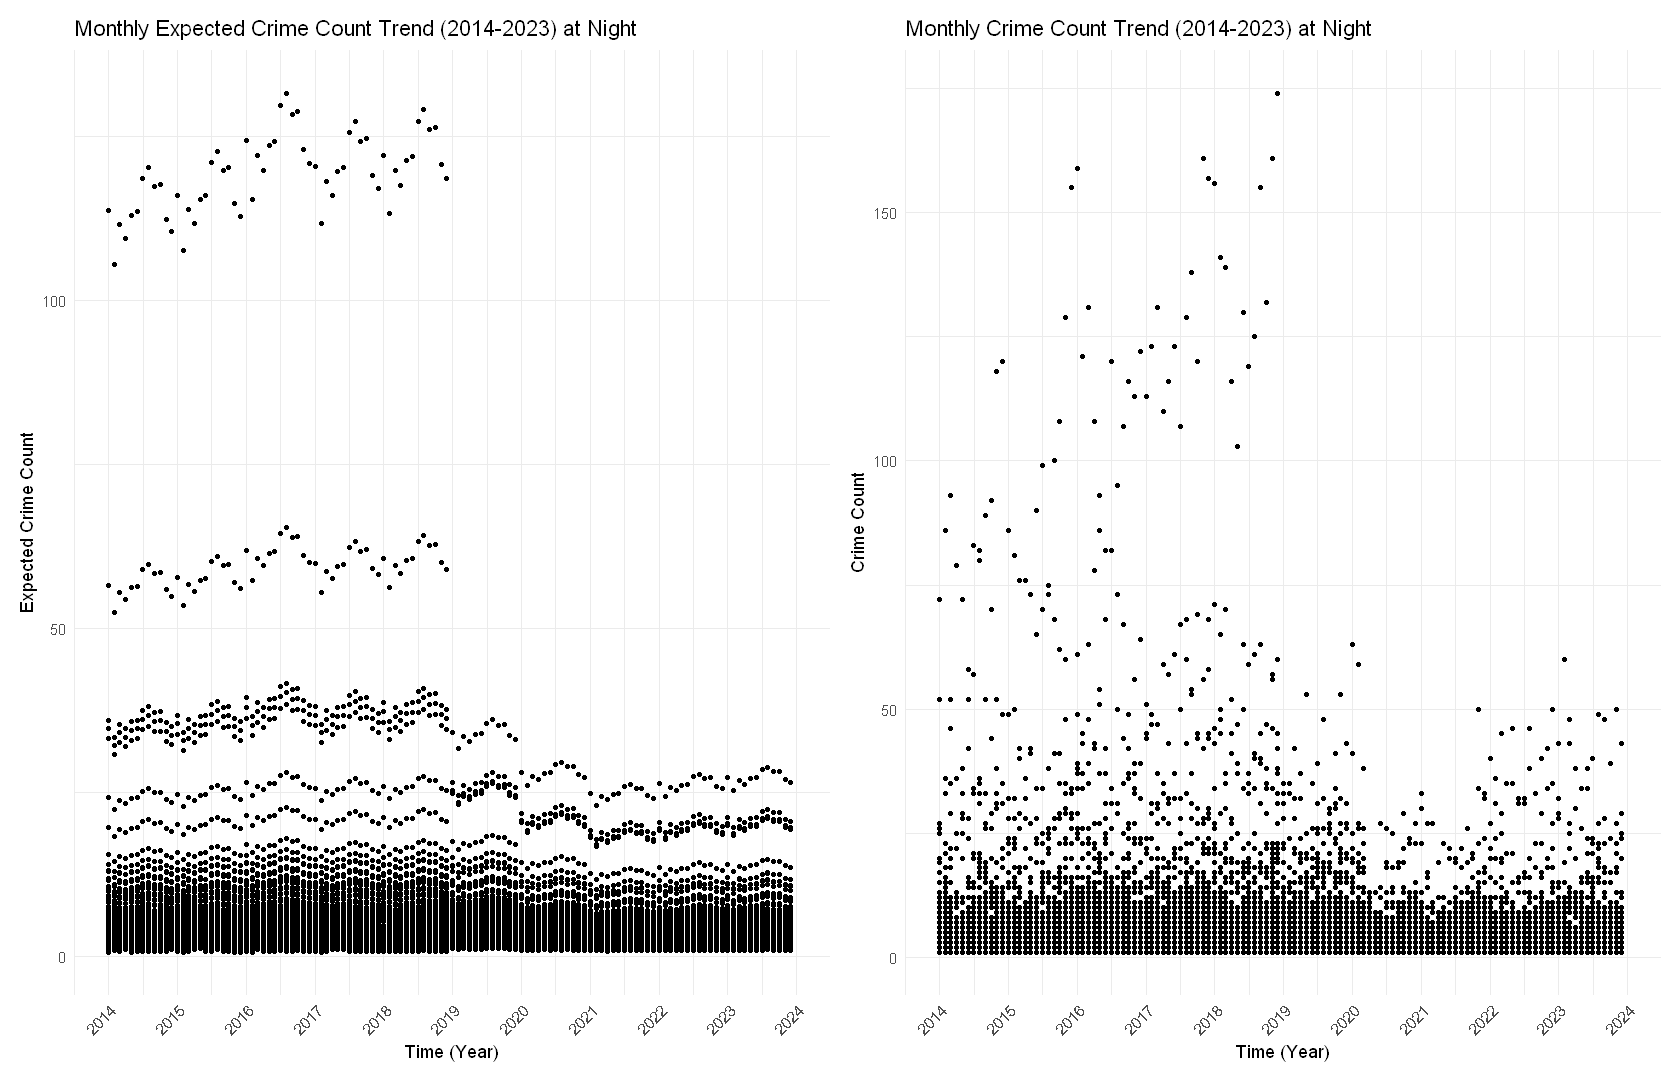

In [6]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_night_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_night_count_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_night_expected_dist + census_night_count_dist

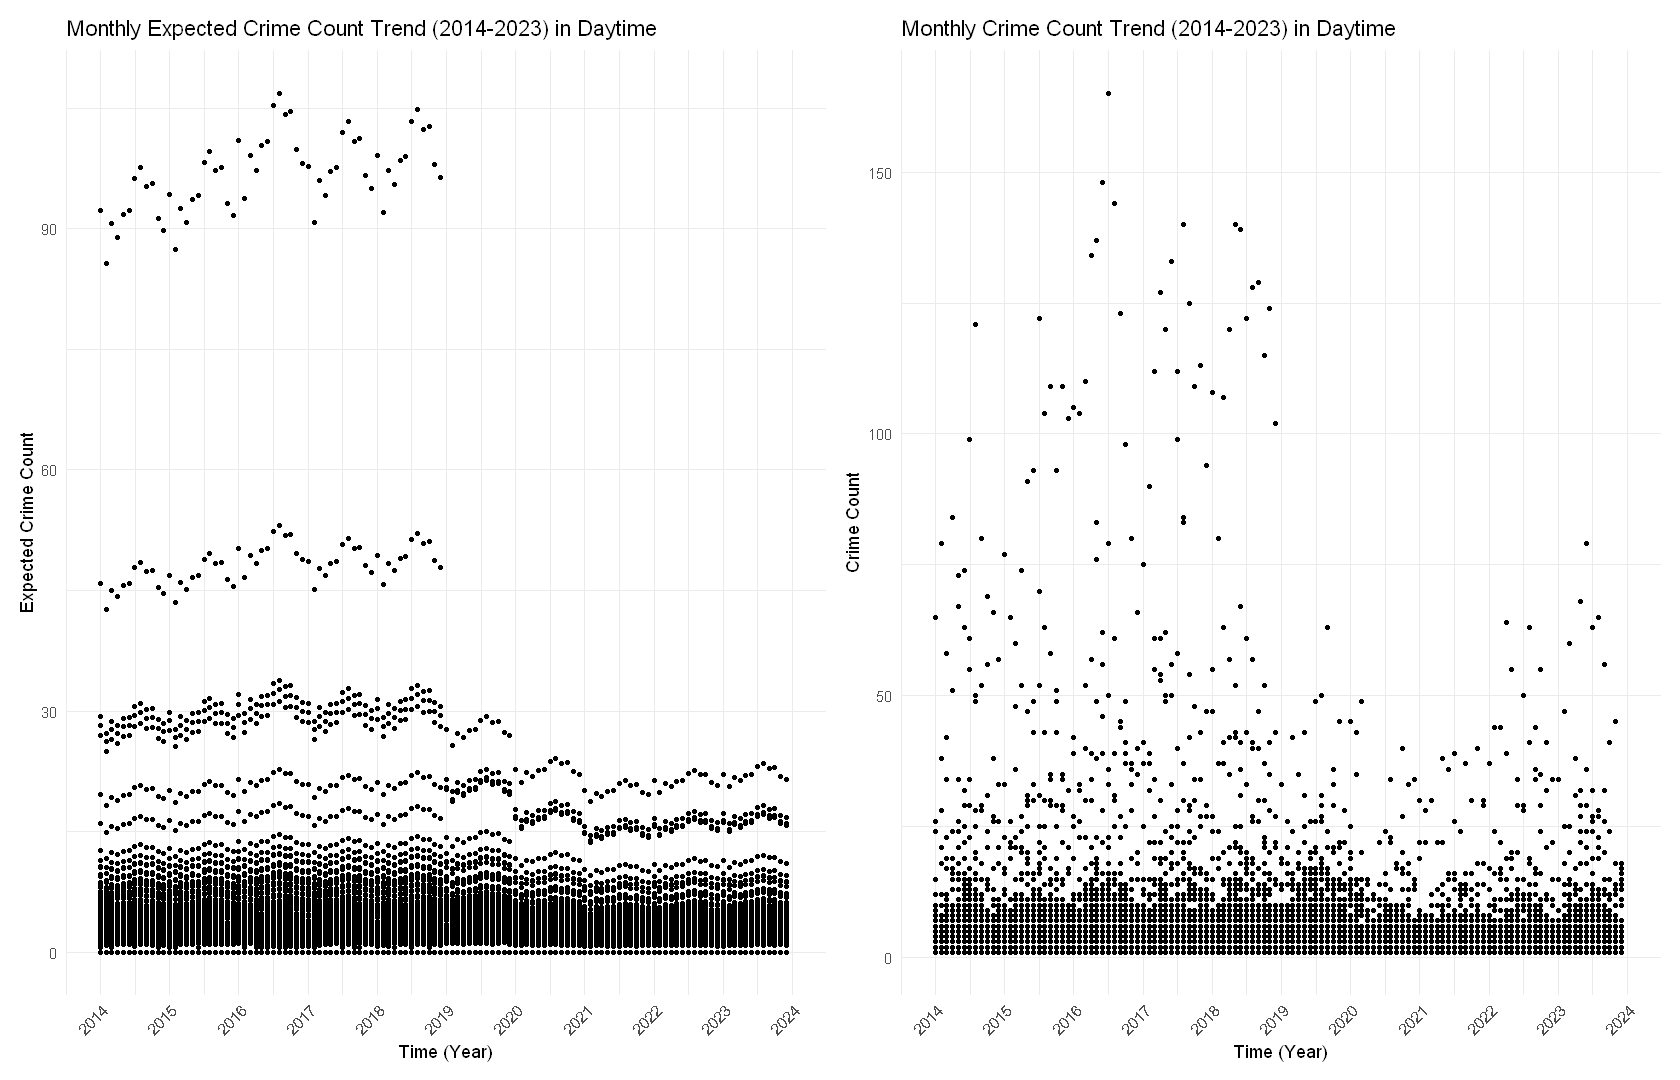

In [7]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_day_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_day_count_dist <- ggplot(census2016_2021_panel_day, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_day_expected_dist + census_day_count_dist

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 4871 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 4871 rows containing missing values or values outside the scale range
(`geom_point()`)."


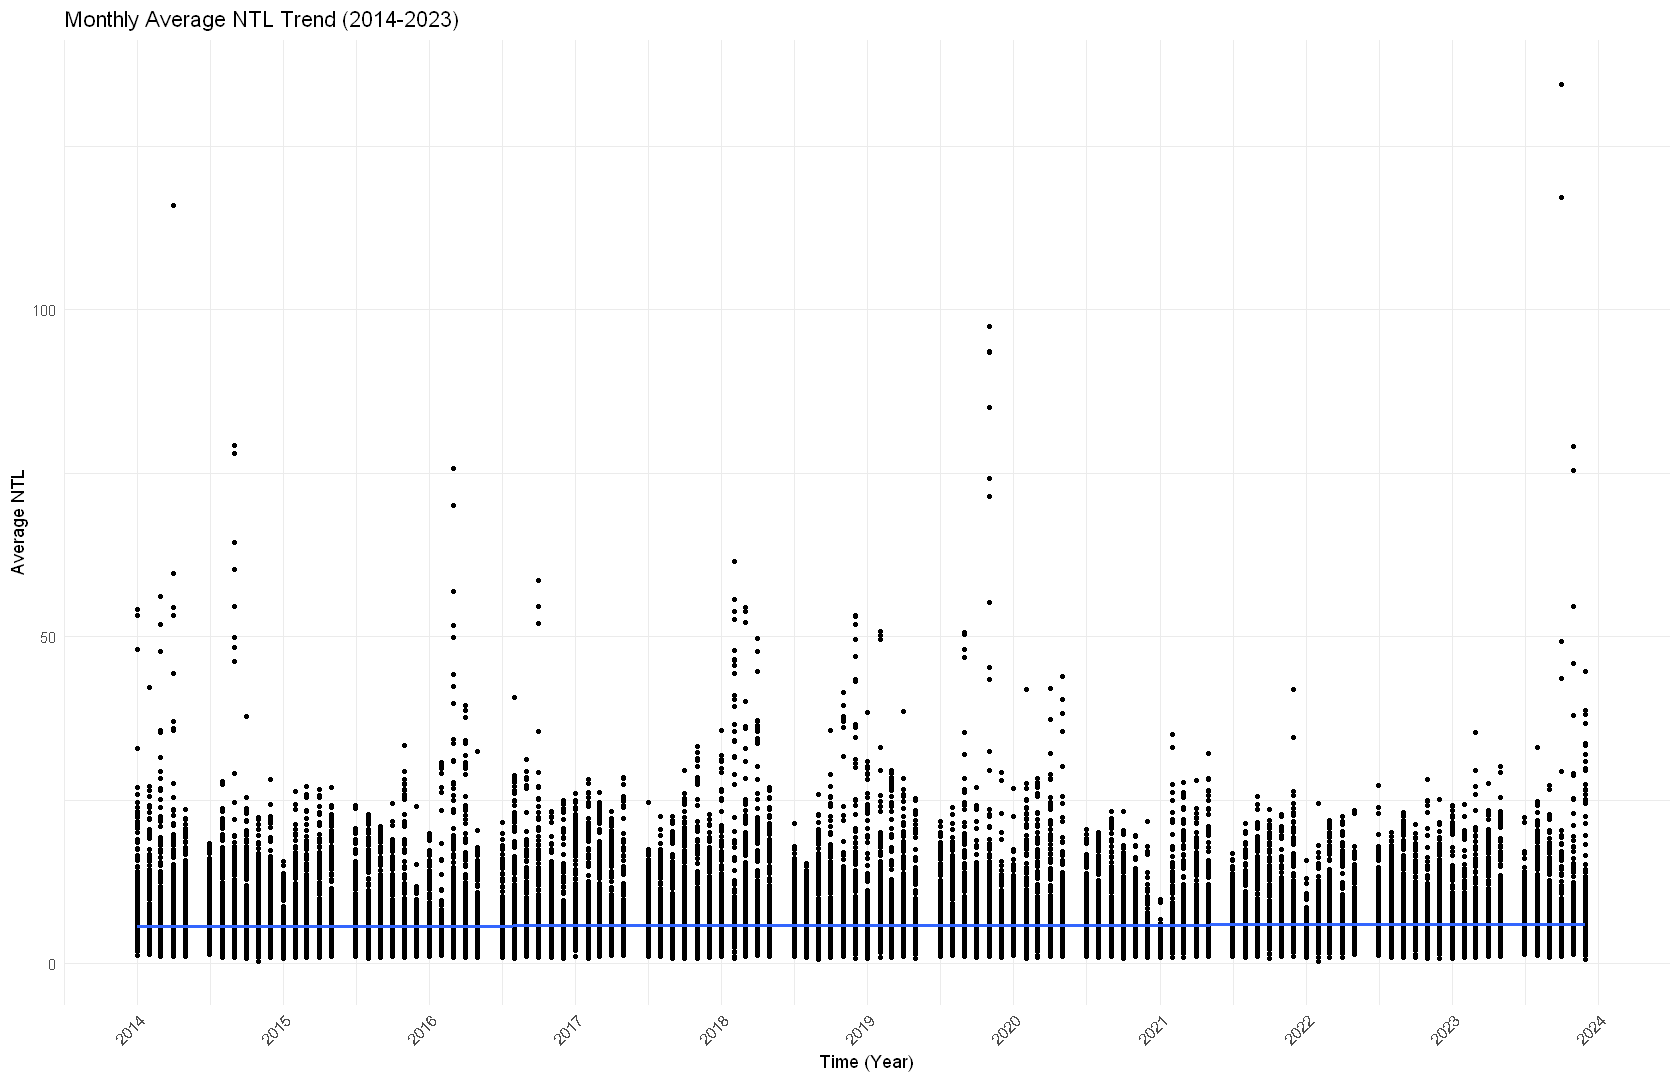

In [8]:
ggplot(census2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Census Divisions Models

In [9]:
library(plm)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead




In [10]:
model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-13.3256913  -0.0723774   0.0043409   0.0773481  12.0741901 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.00018223  0.00168708  -0.1080   0.91398    
year2015              0.06053619  0.00999404   6.0572 1.394e-09 ***
year2016              0.26299303  0.00994779  26.4373 < 2.2e-16 ***
year2017              0.16539276  0.00999037  16.5552 < 2.2e-16 ***
year2018              0.20754716  0.00992207  20.9177 < 2.2e-16 ***
year2019              0.38958828  0.01002093  38.8774 < 2.2e-16 ***
year2020             -0.08923967  0.01020019  -8.7488 < 2.2e-16 ***
year2021             -0.36

In [11]:
model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime, 
    data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-9.0693390 -0.2570527 -0.0030604  0.2310021  8.1900790 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.0084957  0.0014386  -5.9057 3.532e-09 ***
expected_day_crime    0.4141429  0.0024783 167.1100 < 2.2e-16 ***
ntl_mean:is_downtown  0.0030856  0.0018011   1.7132   0.08669 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    19364
Residual Sum of Squares: 12812
R-Squared:      0.33833
Adj. R-Squared: 0.32632
F-statistic: 9335.17 on 3 and 54771 DF, p-value: < 2.22e-16

In [12]:
model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + electric_index, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    electric_index, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-9.10366132 -0.25917867  0.00060493  0.22804573  8.20204810 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.00792395  0.00144088  -5.4994 3.828e-08 ***
expected_day_crime    0.41345709  0.00247975 166.7336 < 2.2e-16 ***
electric_index       -0.00182152  0.00028762  -6.3330 2.423e-10 ***
ntl_mean:is_downtown  0.00245639  0.00180321   1.3622    0.1731    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    19364
Residual Sum of Squares: 12803
R-Squared:      0.33881
Adj. R-Squared: 0.3268
F-statistic: 7016.4 on 4 and 5

In [13]:
model3 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model3)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    electric_index + population_density, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-9.3176959 -0.2456765  0.0023582  0.2186875  8.3532297 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -8.3744e-03  1.4020e-03  -5.9730 2.343e-09 ***
expected_day_crime    3.9782e-01  2.4293e-03 163.7597 < 2.2e-16 ***
electric_index       -3.7300e-03  2.8197e-04 -13.2283 < 2.2e-16 ***
population_density    9.5613e-05  1.7231e-06  55.4898 < 2.2e-16 ***
ntl_mean:is_downtown  3.7399e-03  1.7547e-03   2.1313   0.03307 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    19364
Residual Sum of Squa

In [14]:
# We run bptest to check for heteroskedasticity
bptest(model0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model0
BP = 3353.6, df = 22, p-value < 2.2e-16


The result shows the models are likely heteroskedastic, so we include a clustered standard error to correct for the significance.

In [15]:
clustered_se0 <- sqrt(diag(vcovHC(model0, type = "HC0", cluster = "group")))
clustered_se1 <- sqrt(diag(vcovHC(model1, type = "HC0", cluster = "group")))
clustered_se2 <- sqrt(diag(vcovHC(model2, type = "HC0", cluster = "group")))
clustered_se3 <- sqrt(diag(vcovHC(model3, type = "HC0", cluster = "group")))

We want to have a better interpretability of how crime would change, so we are switching to a $log-log$ model.

In [16]:
model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-0.89739831 -0.02344891  0.00094174  0.02441845  0.68903840 

Coefficients:
                            Estimate Std. Error   t-value  Pr(>|t|)    
log(ntl_mean)              0.0035631  0.0017774    2.0046 0.0450074 *  
year2015                   0.0209370  0.0014992   13.9652 < 2.2e-16 ***
year2016                   0.0893953  0.0014968   59.7256 < 2.2e-16 ***
year2017                   0.0563694  0.0014951   37.7020 < 2.2e-16 ***
year2018                   0.0695568  0.0014827   46.9116 < 2.2e-16 ***
year2019                   0.1338887  0.0014961   89.4917 < 2.2e-16 ***
year2020                  -0.0607089  0.0015235  -39.848

In [71]:
model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.914218 -0.078999  0.012217  0.081261  0.894786 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.03249420  0.00241985 -13.428 < 2.2e-16 ***
expected_day_crime         0.05045450  0.00062394  80.864 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.04478216  0.00604267   7.411 1.272e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    911.85
Residual Sum of Squares: 812.16
R-Squared:      0.10933
Adj. R-Squared: 0.09317
F-statistic: 2241.15 on 3 and 54771 DF, p-value: < 2.22e-16

In [62]:
model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + electric_index + population_density, 
    data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.6483314 -0.0759622  0.0026563  0.0794365  0.7795723 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -2.7150e-02  2.2233e-03 -12.2117 < 2.2e-16 ***
expected_day_crime         4.3144e-02  5.7604e-04  74.8974 < 2.2e-16 ***
electric_index            -3.2883e-03  6.6924e-05 -49.1345 < 2.2e-16 ***
population_density         3.8896e-05  4.0863e-07  95.1844 < 2.2e-16 ***
log(ntl_mean):is_downtown  4.7413e-02  5.5413e-03   8.5563 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Sq

In [63]:
# We run bptest to check for heteroskedasticity
bptest(model_log0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model_log0
BP = 5085.1, df = 22, p-value < 2.2e-16


In [72]:
clustered_log_se0 <- sqrt(diag(vcovHC(model_log0, type = "HC0", cluster = "group")))
clustered_log_se1 <- sqrt(diag(vcovHC(model_log1, type = "HC0", cluster = "group")))
clustered_log_se2 <- sqrt(diag(vcovHC(model_log2, type = "HC0", cluster = "group")))

We run robustness check on the unadjusted crime counts

In [65]:
model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month, 
    data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-42.15451  -0.71260  -0.24973   0.49782  59.76975 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean              0.0158702  0.0066510  2.3861 0.0170297 *  
year2015              0.0647829  0.0393996  1.6443 0.1001299    
year2016              0.3135168  0.0392173  7.9943 1.328e-15 ***
year2017              0.2403124  0.0393852  6.1016 1.057e-09 ***
year2018              0.3469959  0.0391160  8.8710 < 2.2e-16 ***
year2019              0.4591663  0.0395057 11.6228 < 2.2e-16 ***
year2020             -0.0332399  0.0402124 -0.8266 0.4084629    
year2021             -0.3411620  0.0421287 -8.0981 5.697e-16 ***
year2022

In [66]:
model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    electric_index + population_density, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-41.83274  -0.64833  -0.26148   0.56132  59.98031 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -2.3066e-02  5.9125e-03 -3.9012 9.583e-05 ***
day_crime_count       4.1729e-01  4.1804e-03 99.8187 < 2.2e-16 ***
electric_index       -1.5307e-03  1.1869e-03 -1.2897    0.1972    
population_density   -2.7728e-06  7.2165e-06 -0.3842    0.7008    
ntl_mean:is_downtown  5.7642e-02  7.4011e-03  7.7884 6.906e-15 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    254830
Residual Sum of Squares: 215470
R-Squared

In [67]:
model_count_log1 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + day_crime_count + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    day_crime_count + electric_index + population_density, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-2.19799 -0.34103 -0.17034  0.36388  2.38725 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -5.8409e-02  9.7789e-03 -5.9729 2.345e-09 ***
day_crime_count            3.6498e-02  1.0338e-03 35.3047 < 2.2e-16 ***
electric_index            -2.8574e-03  2.9382e-04 -9.7249 < 2.2e-16 ***
population_density         1.7670e-06  1.7851e-06  0.9899  0.322247    
log(ntl_mean):is_downtown  7.7531e-02  2.4371e-02  3.1813  0.001467 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    13512
Residual Sum

In [68]:
clustered_count_se0 <- sqrt(diag(vcovHC(model_count0, type = "HC0", cluster = "group")))
clustered_count_se1 <- sqrt(diag(vcovHC(model_count1, type = "HC0", cluster = "group")))
clustered_count_log_se1 <- sqrt(diag(vcovHC(model_count_log1, type = "HC0", cluster = "group")))

##### Summary Tables

In [25]:
census_summary1 <- stargazer(list(model0, model1, model2, model3),
          type = "text",                   
          title = "Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
          dep.var.labels = "Expected Crime",
          covariate.labels = c("Average NTL",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "Population Density",
                               "Average NTL x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_se0, clustered_se1, clustered_se2, clustered_se3),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


Regression of Expected Crime on Average NTL in the Scale of Census Divisions
                                                                                               Dependent variable:                                                                      
                          --------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                  Expected Crime                                                                        
                                            (1)                                     (2)                                     (3)                                    (4)                  
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
census_summary2 <- stargazer(list(model_log0, model_log1, model_log2),
          type = "text",                   
          title = "log -log Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
          dep.var.labels = "log(Expected Crime)",
          covariate.labels = c("log (Average NTL)",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "Population Density",
                               "log(Average NTL) x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_log_se0, clustered_log_se1, clustered_log_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


log -log Regression of Expected Crime on Average NTL in the Scale of Census Divisions
                                                                                                    Dependent variable:                                                                     
                               -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                    log(Expected Crime)                                                                     
                                                       (1)                                                  (2)                                                  (3)                        
-------------------------------------------------------------------------------------------------------------------------------------------------------------

In [70]:
census_summary3 <- stargazer(list(model_count0, model_count1, model_count_log1),
          type = "text",                   
          title = "Regression of Crime Counts on Average NTL in the Scale of Census Divisions",
          dep.var.labels = c("Crime Count", "log (Crime Count)"),
          covariate.labels = c("Average NTL",
                               "log (Average NTL)",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "Population Density",
                               "Average NTL x is Downtown",
                               "log(Average NTL) x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_count_se0, clustered_count_se1, clustered_count_log_se1),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


Regression of Crime Counts on Average NTL in the Scale of Census Divisions
                                                                                                    Dependent variable:                                                                     
                               -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Crime Count                                                                 log (Crime Count)                 
                                                       (1)                                                  (2)                                                  (3)                        
------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Explorations on 22 Neighborhoods

In [18]:
neighborhood2016_2021_panel <- read_csv("neighborhood2016_2021_panel.csv")

Rows: 5279 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (14): year, month, population, area_sq_km, population_density, income, ...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income))|>
    filter(!is.na(income))|>
    glimpse()

Rows: 2,640
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

In [82]:
# Adding day crime as a control
neighborhood2016_2021_panel_day <- neighborhood2016_2021_panel|>
    filter(time_category == "day")|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(neighborhood, date, day_crime_count, expected_day_crime)

neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel_night|>
    left_join(neighborhood2016_2021_panel_day, by = c("date", "neighborhood"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    glimpse()

Rows: 2,640
Columns: 19
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

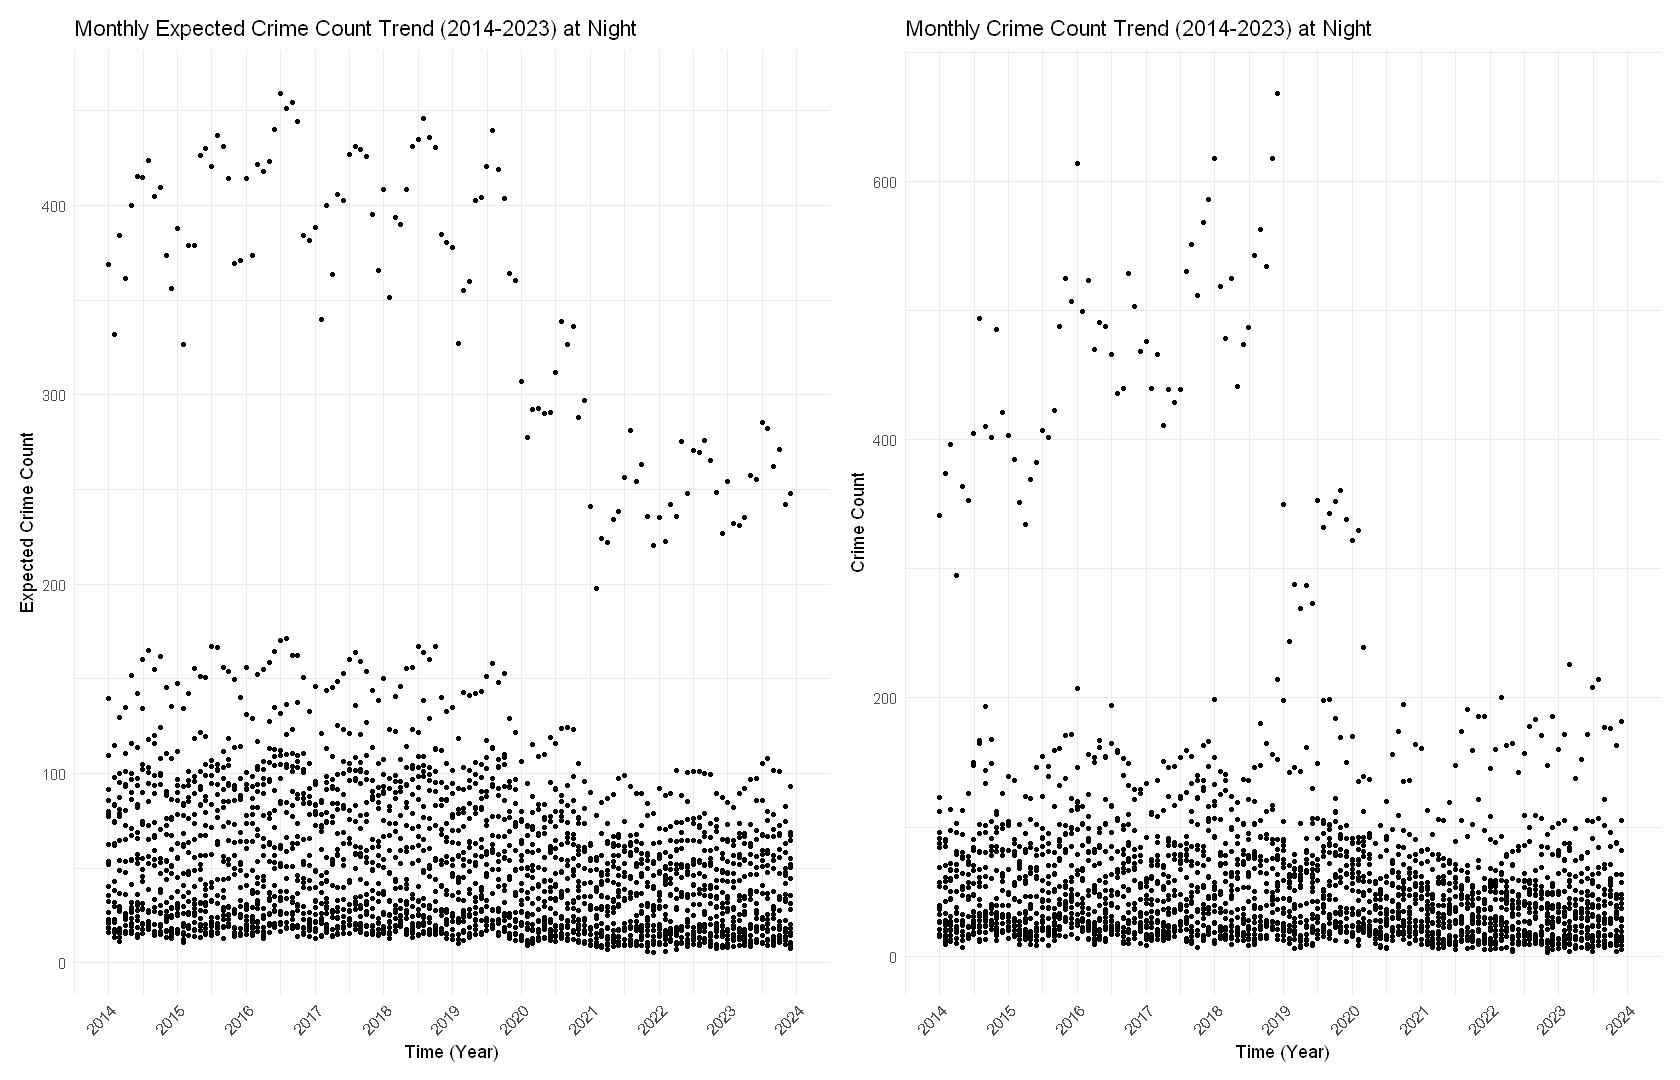

In [83]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

neighborhood_night_expected_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
neighborhood_night_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_night_expected_dist + neighborhood_night_count_dist

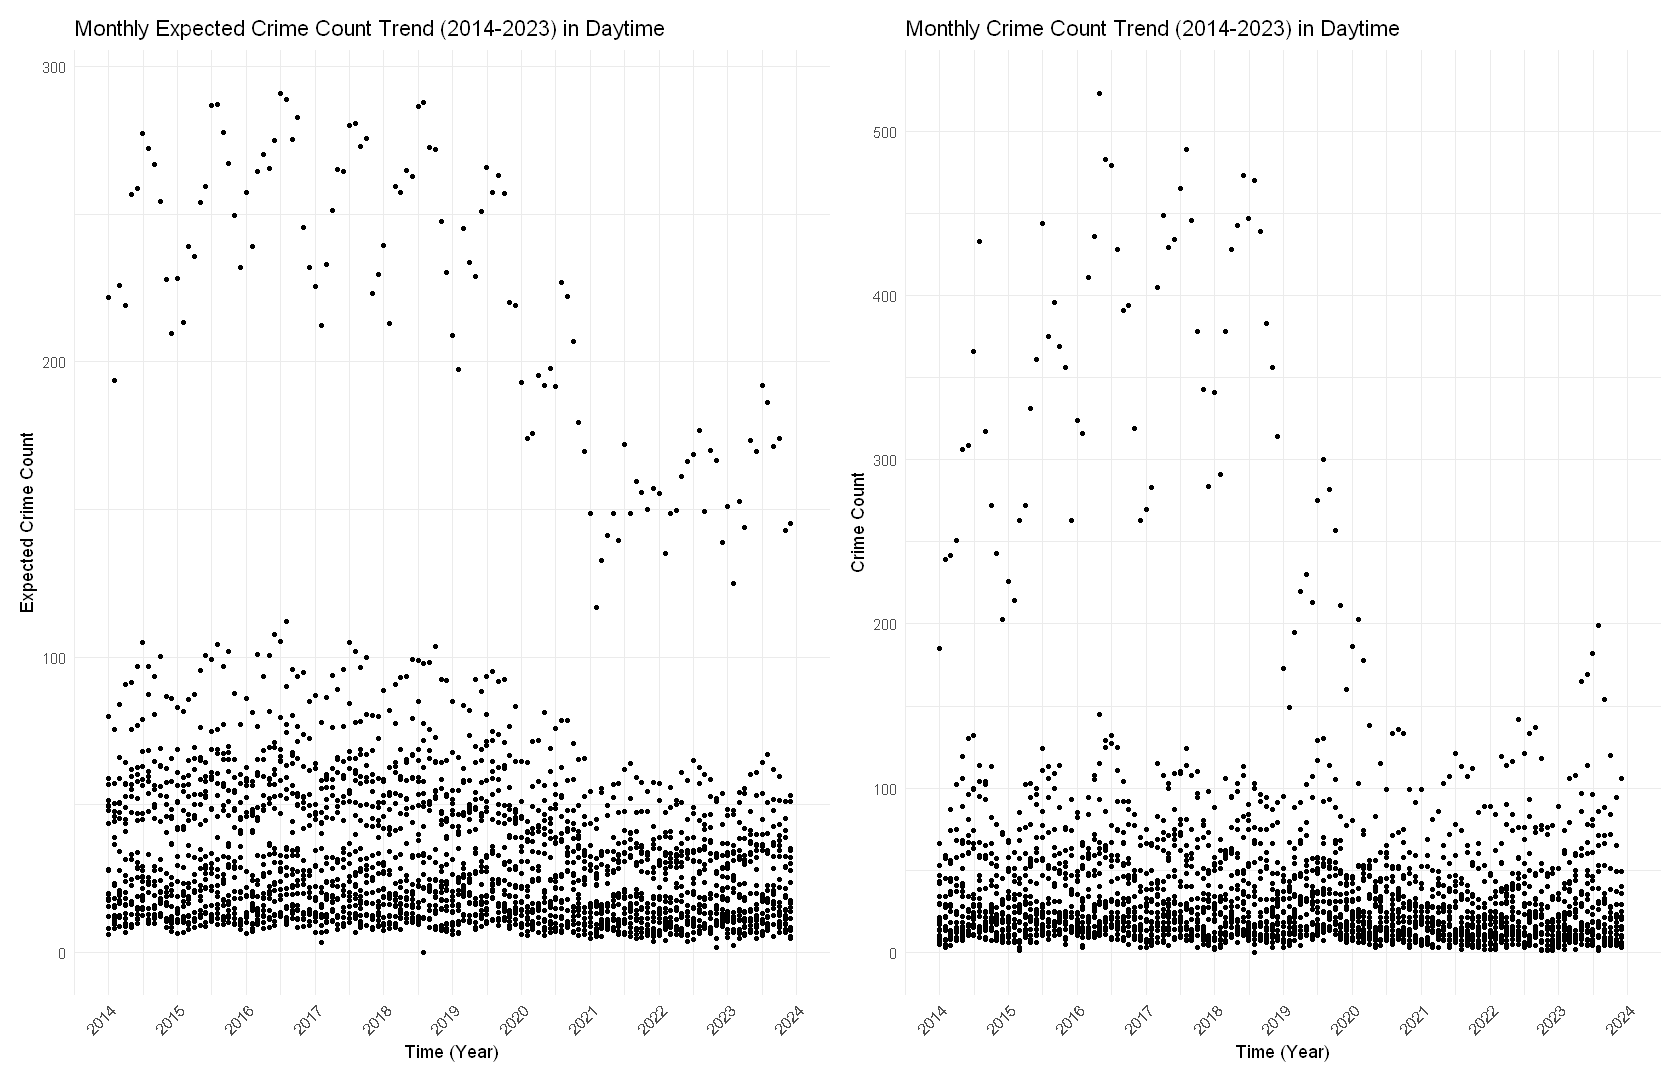

In [84]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

neighborhood_day_expected_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
neighborhood_day_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_day_expected_dist + neighborhood_day_count_dist

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 220 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 220 rows containing missing values or values outside the scale range
(`geom_point()`)."


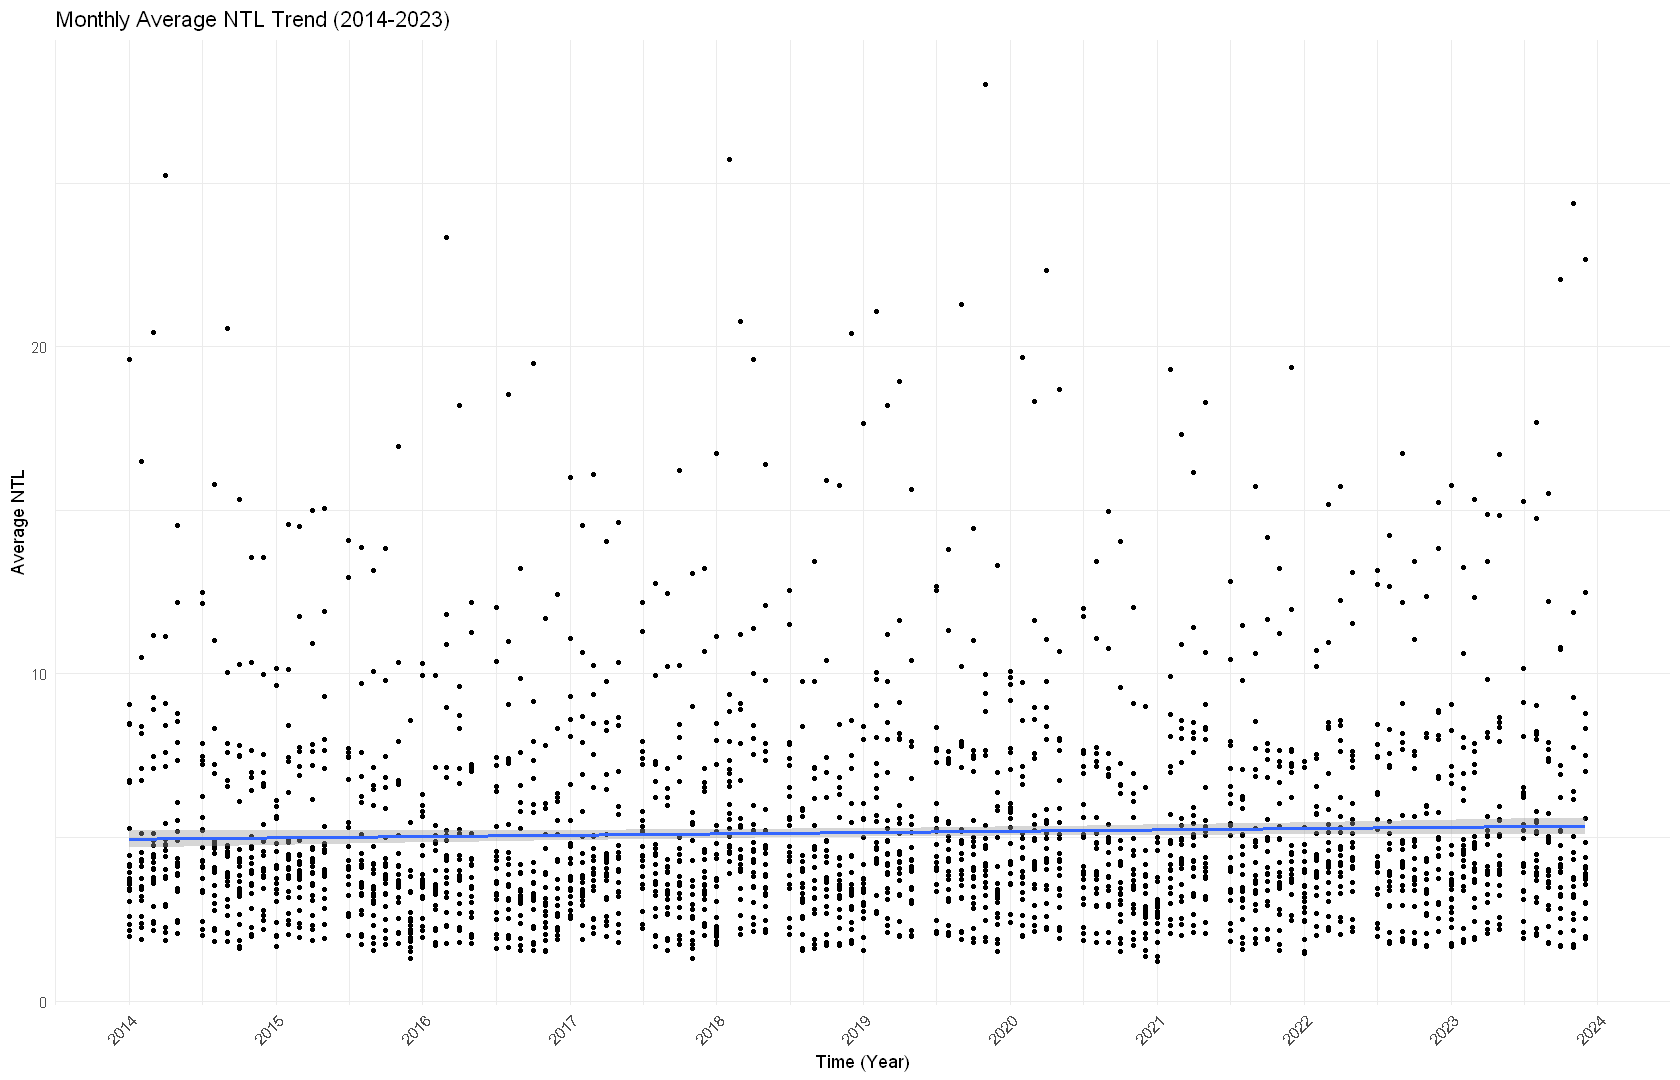

In [85]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Neighborhood Models

In [34]:
neighborhood_model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-117.2058   -6.4358   -0.6393    6.5498   95.4872 

Coefficients:
                      Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean               0.18623    0.45710   0.4074 0.6837323    
year2015               1.84161    1.45502   1.2657 0.2057468    
year2016               6.21552    1.46203   4.2513 2.208e-05 ***
year2017               1.89602    1.44793   1.3095 0.1905033    
year2018               2.40915    1.44379   1.6686 0.0953231 .  
year2019              -0.55113    1.44415  -0.3816 0.7027716    
year2020             -13.97351    1.44448  -9.6737 < 2.2e-16 ***
year2021             -25.95817    1.44429 -17.9730 < 2.2e-16 **

In [35]:
neighborhood_model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime, 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-41.404516  -3.578791   0.094942   3.924455  43.274775 

Coefficients:
                      Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.774414   0.192874  -4.0151 6.124e-05 ***
expected_day_crime    1.412306   0.011614 121.6031 < 2.2e-16 ***
ntl_mean:is_downtown  0.943185   0.264116   3.5711 0.0003625 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    990010
Residual Sum of Squares: 137170
R-Squared:      0.86145
Adj. R-Squared: 0.86006
F-statistic: 4963.56 on 3 and 2395 DF, p-value: < 2.22e-16

In [36]:
neighborhood_model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime  + electric_index + population_density, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    electric_index + population_density, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-43.28378  -3.42855   0.40558   3.79147  39.61502 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.55451678  0.17329691  -3.1998  0.001393 ** 
expected_day_crime    1.36958285  0.01085274 126.1970 < 2.2e-16 ***
electric_index       -0.24650763  0.02029163 -12.1482 < 2.2e-16 ***
population_density    0.00513102  0.00022283  23.0271 < 2.2e-16 ***
ntl_mean:is_downtown  0.74325550  0.23679433   3.1388  0.001717 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    990010
Residual Sum of Square

In [37]:
n_clustered_se0 <- sqrt(diag(vcovHC(neighborhood_model0, type = "HC0", cluster = "group")))
n_clustered_se1 <- sqrt(diag(vcovHC(neighborhood_model1, type = "HC0", cluster = "group")))
n_clustered_se2 <- sqrt(diag(vcovHC(neighborhood_model2, type = "HC0", cluster = "group")))

In [38]:
neighborhood_model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.8435147 -0.0685877  0.0004332  0.0622132  0.6400489 

Coefficients:
                            Estimate Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -0.0236981  0.0209554  -1.1309 0.2582168    
year2015                   0.0268966  0.0131330   2.0480 0.0406675 *  
year2016                   0.0867655  0.0132244   6.5610 6.537e-11 ***
year2017                   0.0280066  0.0130337   2.1488 0.0317518 *  
year2018                   0.0268494  0.0129874   2.0673 0.0388093 *  
year2019                   0.0012075  0.0129862   0.0930 0.9259256    
year2020                  -0.2021554  0.0129955 -15.5558 < 2.2e-16

In [39]:
neighborhood_model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.083277 -0.127276  0.030126  0.132101  0.855220 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.15092254  0.02664530 -5.6641 1.655e-08 ***
expected_day_crime         0.01017763  0.00032506 31.3096 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.16937754  0.07970787  2.1250   0.03369 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    153.82
Residual Sum of Squares: 107.61
R-Squared:      0.30044
Adj. R-Squared: 0.29343
F-statistic: 342.858 on 3 and 2395 DF, p-value: < 2.22e-16

In [87]:
neighborhood_model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + electric_index + population_density, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + electric_index + population_density, 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.8011695 -0.1231793  0.0059898  0.1263620  0.5058996 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -9.4413e-02  2.1605e-02  -4.3699 1.296e-05 ***
expected_day_crime         8.0539e-03  2.7433e-04  29.3591 < 2.2e-16 ***
electric_index            -1.2742e-02  5.1289e-04 -24.8436 < 2.2e-16 ***
population_density         1.6554e-04  5.6361e-06  29.3711 < 2.2e-16 ***
log(ntl_mean):is_downtown  1.3591e-01  6.4353e-02   2.1119    0.0348 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Su

In [90]:
neighborhood_model_log3 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + electric_index + population_density,
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log3)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + electric_index + population_density, 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.8011695 -0.1231793  0.0059898  0.1263620  0.5058996 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -9.4413e-02  2.1605e-02  -4.3699 1.296e-05 ***
expected_day_crime         8.0539e-03  2.7433e-04  29.3591 < 2.2e-16 ***
electric_index            -1.2742e-02  5.1289e-04 -24.8436 < 2.2e-16 ***
population_density         1.6554e-04  5.6361e-06  29.3711 < 2.2e-16 ***
log(ntl_mean):is_downtown  1.3591e-01  6.4353e-02   2.1119    0.0348 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Su

In [ ]:
neighborhood_model_log4 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + electric_index + log(population_density),
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log4)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    neighborhood + electric_index + log(population_density), 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.4487009 -0.1202669  0.0070776  0.1233597  0.3932395 

Coefficients:
                          Estimate Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)           -0.0792482  0.0188792  -4.1976 2.796e-05 ***
expected_day_crime       0.0079580  0.0002545  31.2690 < 2.2e-16 ***
electric_index          -0.0127660  0.0004739 -26.9383 < 2.2e-16 ***
log(population_density)  0.8410231  0.0225339  37.3225 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    153.82
Residual Sum of Squares: 60.263
R-Squared:      0.60824
Adj. R-

In [86]:
bptest(neighborhood_model_log4, studentize = TRUE)


	studentized Breusch-Pagan test

data:  neighborhood_model_log4
BP = 342.68, df = 25, p-value < 2.2e-16


In [43]:
n_clustered_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_log0, type = "HC0", cluster = "group")))
n_clustered_log_se1 <- sqrt(diag(vcovHC(neighborhood_model_log1, type = "HC0", cluster = "group")))
n_clustered_log_se2 <- sqrt(diag(vcovHC(neighborhood_model_log2, type = "HC0", cluster = "group")))
n_clustered_log_se3 <- sqrt(diag(vcovHC(neighborhood_model_log3, type = "HC0", cluster = "group")))

We check the robustness by running models on crime counts.

In [44]:
neighborhood_model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month, 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-231.7918  -12.1348   -1.6959   12.1291  314.5134 

Coefficients:
                      Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean               0.86489    0.99555  0.8688 0.3850698    
year2015               2.35879    3.16899  0.7443 0.4567485    
year2016               9.91217    3.18427  3.1129 0.0018749 ** 
year2017               6.50939    3.15356  2.0641 0.0391131 *  
year2018              10.52438    3.14455  3.3469 0.0008300 ***
year2019              -0.86752    3.14533 -0.2758 0.7827168    
year2020             -15.80147    3.14605 -5.0226 5.475e-07 ***
year2021             -27.60326    3.14563 -8.7751 < 2.2e-16 ***
year2022  

In [45]:
neighborhood_model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + electric_index + population_density, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    electric_index + population_density, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-127.0269   -8.0176   -0.6703    6.4968  259.7389 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -3.82734419  0.53769391 -7.1181 1.441e-12 ***
day_crime_count       1.00646290  0.01425867 70.5860 < 2.2e-16 ***
electric_index       -0.31221891  0.06092282 -5.1248 3.216e-07 ***
population_density    0.00253707  0.00069116  3.6707 0.0002471 ***
ntl_mean:is_downtown  4.64464252  0.73517916  6.3177 3.156e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    3385000
Residual Sum of Squares: 1052700


In [46]:
neighborhood_model_count_log1 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + day_crime_count + electric_index, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_count_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    day_crime_count + electric_index, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.612330 -0.191403  0.020084  0.216642  1.029663 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -0.28528127  0.04044417  -7.0537 2.271e-12 ***
day_crime_count            0.00494052  0.00021702  22.7651 < 2.2e-16 ***
electric_index            -0.01040533  0.00092106 -11.2971 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.32729023  0.12044283   2.7174  0.006627 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    328.55
Residual Sum of Squares: 245.22
R-Squared:      0.25364
Adj. R-Squared: 0.24585
F-

In [47]:
n_clustered_count_se0 <- sqrt(diag(vcovHC(neighborhood_model_count0, type = "HC0", cluster = "group")))
n_clustered_count_se1 <- sqrt(diag(vcovHC(neighborhood_model_count1, type = "HC0", cluster = "group")))
n_clustered_count_log_se1 <- sqrt(diag(vcovHC(neighborhood_model_count_log1, type = "HC0", cluster = "group")))

##### Summary Tables

In [48]:
neighborhood_summary1 <- stargazer(list(neighborhood_model0, neighborhood_model1, neighborhood_model2),
          type = "text",                   
          title = "Regression of Expected Crime on Average NTL in the Scale of Neighborhoods",
          dep.var.labels = "Expected Crime",
          covariate.labels = c("Average NTL",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "Population Density",
                               "Average NTL x is Downtown"),
          se = list(n_clustered_se0, n_clustered_se1, n_clustered_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


Regression of Expected Crime on Average NTL in the Scale of Neighborhoods
                                                                                               Dependent variable:                                                                     
                          -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                 Expected Crime                                                                        
                                                  (1)                                                  (2)                                                  (3)                        
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Avera

In [49]:
neighborhood_summary2 <- stargazer(neighborhood_model_log0, neighborhood_model_log1, neighborhood_model_log2,
          type = "text",                   
          title = "log -log Regression of Expected Crime on Average NTL in the Scale of Neighborhoods",
          dep.var.labels = "log(Expected Crime)",
          covariate.labels = c("log (Average NTL)",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "log(Average NTL) x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(n_clustered_log_se0, n_clustered_log_se1, n_clustered_log_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))  


log -log Regression of Expected Crime on Average NTL in the Scale of Neighborhoods
                                                                                                    Dependent variable:                                                                     
                               -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                    log(Expected Crime)                                                                     
                                                       (1)                                                  (2)                                                  (3)                        
----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [50]:
neighborhood_summary3 <- stargazer(neighborhood_model_count0, neighborhood_model_count1, neighborhood_model_count_log1,
          type = "text",                   
          title = "Regression of Crime Count on Average NTL in the Scale of Neighborhoods",
          dep.var.labels = c("Crime Count", "log(Crime Count)"),
          covariate.labels = c("Average NTL",
                               "log (Average NTL)",
                               "Expected Day Crime",
                               "Electricity Price Index",
                               "Population Density",
                               "Average NTL x is Downtown",
                               "log(Average NTL) x is Downtown"),
          se = list(n_clustered_count_se0, n_clustered_count_se1, n_clustered_count_log_se1),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))  


Regression of Crime Count on Average NTL in the Scale of Neighborhoods
                                                                                                    Dependent variable:                                                                     
                               -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Crime Count                                                                 log(Crime Count)                  
                                                       (1)                                                  (2)                                                  (3)                        
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Heterougeneous Analysis on Two Scales

In [51]:
# Studying from the scale of census divisions
census2016_2021_panel_dt <- census2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

census2016_2021_panel_ut <- census2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [52]:
model_dt0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + electric_index, 
                            index = c("name", "date"),
                            data = census2016_2021_panel_dt, 
                            model = "within", 
                            effect = "individual")

summary(model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    electric_index, data = census2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 53, T = 16-110, N = 4251

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-3.29776 -0.54494 -0.17027  0.35155  9.57489 

Coefficients:
                      Estimate  Std. Error  t-value Pr(>|t|)    
ntl_mean           -0.00354740  0.00183832  -1.9297  0.05371 .  
expected_day_crime  0.93223220  0.00785497 118.6805  < 2e-16 ***
electric_index     -0.00003084  0.00177195  -0.0174  0.98611    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    12300
Residual Sum of Squares: 2820.4
R-Squared:      0.77069
Adj. R-Squared: 0.76769
F-statistic: 4699.73 on 3 and 4195 DF, p-value: < 2.22e-16

In [53]:
model_ut0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + electric_index, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    electric_index, data = census2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 937, T = 11-110, N = 51361

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-5.7743214 -0.1527136 -0.0072724  0.1555902  5.1176048 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean           -0.00783023  0.00100666  -7.7784 7.481e-15 ***
expected_day_crime  0.20098840  0.00205809  97.6576 < 2.2e-16 ***
electric_index     -0.00299149  0.00020936 -14.2889 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    6889.9
Residual Sum of Squares: 5750.1
R-Squared:      0.16543
Adj. R-Squared: 0.14989
F-statistic: 3331.54 on 3 and 50421 DF, p-value: < 2.22e-16

In [54]:
model_dt_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + electric_index, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    electric_index, data = census2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 53, T = 16-110, N = 4251

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-0.48326968 -0.06324798 -0.00020796  0.06003740  0.60523532 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)       0.01213441  0.00486963  2.4919  0.012746 *  
expected_day_crime  0.05819288  0.00102520 56.7626 < 2.2e-16 ***
electric_index     -0.00066698  0.00023133 -2.8833  0.003956 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    85.107
Residual Sum of Squares: 48.052
R-Squared:      0.4354
Adj. R-Squared: 0.42799
F-statistic: 1078.33 on 3 and 4195 DF, p-value: < 2.22e-16

In [55]:
model_ut_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + electric_index, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    electric_index, data = census2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 937, T = 11-110, N = 51361

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.9573228 -0.0782863  0.0043372  0.0815805  0.9072855 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)      -0.02582682  0.00242305 -10.659 < 2.2e-16 ***
expected_day_crime  0.04574026  0.00073988  61.821 < 2.2e-16 ***
electric_index     -0.00267895  0.00007534 -35.558 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    824.41
Residual Sum of Squares: 743.13
R-Squared:      0.098597
Adj. R-Squared: 0.08181
F-statistic: 1838.37 on 3 and 50421 DF, p-value: < 2.22e-16

In [56]:
# Studying from the scale of neighborhoods
neighborhood2016_2021_panel_dt <- neighborhood2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

neighborhood2016_2021_panel_ut <- neighborhood2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [57]:
neighborhood_model_dt0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + electric_index, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    electric_index, data = neighborhood2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-37.1212 -10.3941  -1.0637   8.5036  45.3877 

Coefficients:
                    Estimate Std. Error t-value Pr(>|t|)    
ntl_mean            0.183466   0.405229  0.4527  0.65166    
expected_day_crime  1.441133   0.037973 37.9511  < 2e-16 ***
electric_index     -0.541216   0.255728 -2.1164  0.03665 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    598370
Residual Sum of Squares: 30504
R-Squared:      0.94902
Adj. R-Squared: 0.94758
F-statistic: 657.759 on 3 and 106 DF, p-value: < 2.22e-16

In [58]:
neighborhood_model_ut0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + electric_index, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    electric_index, data = neighborhood2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-26.631344  -3.447846   0.078006   3.711078  32.377228 

Coefficients:
                    Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean           -0.697450   0.167987  -4.1518  3.42e-05 ***
expected_day_crime  1.249671   0.017082  73.1562 < 2.2e-16 ***
electric_index     -0.202944   0.020243 -10.0255 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    391640
Residual Sum of Squares: 98072
R-Squared:      0.74958
Adj. R-Squared: 0.74707
F-statistic: 2280.94 on 3 and 2286 DF, p-value: < 2.22e-16

In [59]:
neighborhood_model_dt_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + electric_index, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    electric_index, data = neighborhood2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.1547329 -0.0367195 -0.0074776  0.0319809  0.1548530 

Coefficients:
                      Estimate  Std. Error t-value Pr(>|t|)    
log(ntl_mean)       0.01328061  0.02016191  0.6587  0.51152    
expected_day_crime  0.00440418  0.00012723 34.6170  < 2e-16 ***
electric_index     -0.00215244  0.00085742 -2.5104  0.01357 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    5.7421
Residual Sum of Squares: 0.34295
R-Squared:      0.94027
Adj. R-Squared: 0.93858
F-statistic: 556.252 on 3 and 106 DF, p-value: < 2.22e-16

In [60]:
neighborhood_model_ut_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + electric_index, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    electric_index, data = neighborhood2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.0384747 -0.0979726  0.0069643  0.1117984  0.7970088 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)      -0.09098960  0.02352113  -3.8684 0.0001126 ***
expected_day_crime  0.01657446  0.00048520  34.1598 < 2.2e-16 ***
electric_index     -0.00825455  0.00057493 -14.3575 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    148.08
Residual Sum of Squares: 79.174
R-Squared:      0.46534
Adj. R-Squared: 0.45996
F-statistic: 663.207 on 3 and 2286 DF, p-value: < 2.22e-16